In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns 

In [2]:
data = {
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20],
    # "HitRate": [0.5604, 0.6430, 0.6453, 0.6447, 0.6271],
    "nDCG": [0.3208, 0.3743, 0.3730, 0.3737, 0.3646],
    "Precision": [0.0560, 0.0643, 0.0645, 0.0644, 0.0627],
    "Recall": [0.5604, 0.6430, 0.6453, 0.6447, 0.6271],
}

In [3]:
df = pd.DataFrame(data)
df = df.sort_values("nr", ascending=False)
df

,nr,nDCG,Precision,Recall
0,0.95,0.3208,0.0560,0.5604
1,0.80,0.3743,0.0643,0.6430
2,0.60,0.3730,0.0645,0.6453
3,0.40,0.3737,0.0644,0.6447
4,0.20,0.3646,0.0627,0.6271


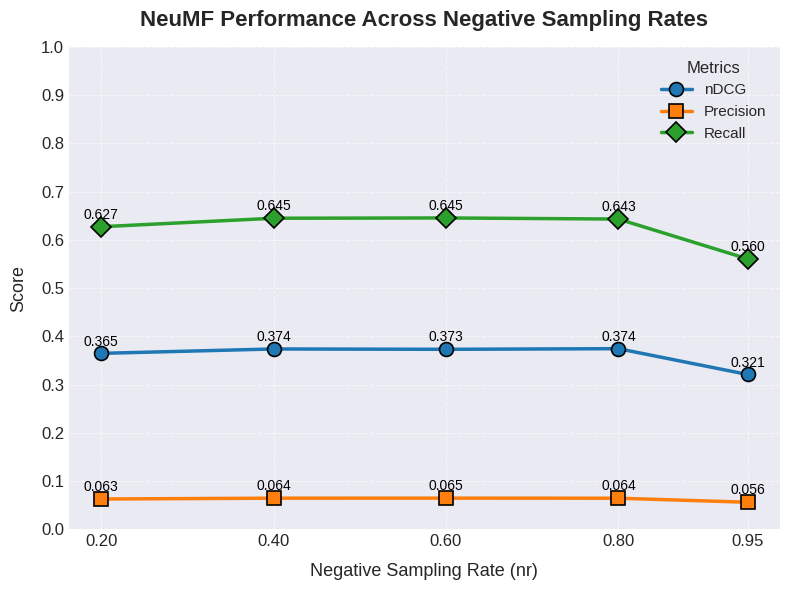

In [ ]:
plt.figure(figsize=(8, 6))

markers = {
    "nDCG": "o",
    "Precision": "s",
    "Recall": "D"
}

for metric in ["nDCG", "Precision", "Recall"]:
    plt.plot(
        df["nr"],
        df[metric],
        marker=markers[metric],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=1.2,
        linewidth=2.5,
        label=metric
    )

    for x, y in zip(df["nr"], df[metric]):
        plt.text(
            x, y + 0.01,
            f"{y:.3f}",
            ha="center", va="bottom",
            fontsize=10,
            fontweight="medium",
            color="black"
        )

plt.title("NeuMF Performance Across Negative Sampling Rates", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Negative Sampling Rate (nr)", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)

plt.xticks(df["nr"], fontsize=12, fontweight="medium")
plt.yticks(np.arange(0, 1.05, 0.1), fontsize=12, fontweight="medium")  # clearer & evenly spaced y-ticks
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(title="Metrics", fontsize=11, title_fontsize=12, loc="best")

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/metrics_vs_neg_samplerate_combined.png", dpi=300)
plt.show()


# Multiple TopK

In [7]:
data = {
    "TopK": [5]*5 + [10]*5 + [20]*5 + [50]*5,
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20]*4,
    "HitRate": [
        0.4018211920529801, 0.46605960264900664, 0.4690397350993378, 0.469205298013245, 0.4471854304635762,
        0.5604304635761589, 0.643046357615894, 0.645364238410596, 0.6447019867549669, 0.6271523178807947,
        0.7208609271523179, 0.802317880794702, 0.8082781456953643, 0.8092715231788079, 0.7933774834437086,
        0.9183774834437086, 0.9600993377483443, 0.9586092715231788, 0.9587748344370861, 0.9544701986754967
    ],
    "nDCG": [
        0.2697065552100979, 0.3172547265543212, 0.3160255669227221, 0.3169896272405769, 0.3063505371459467,
        0.3208008811891443, 0.3743937717980421, 0.37306293288034487, 0.3737129001338871, 0.36458616168972874,
        0.361396341939741, 0.4146885684133939, 0.4144972928330808, 0.41558253601350625, 0.40681330024589923,
        0.4008453517855019, 0.4463834966894295, 0.44479043540765123, 0.4457995335409477, 0.4391717788818347
    ],
    "Precision": [
        0.08036423841059603, 0.09321192052980132, 0.09380794701986755, 0.09384105960264902, 0.08943708609271524,
        0.056043046357615894, 0.06430463576158942, 0.0645364238410596, 0.06447019867549669, 0.06271523178807947,
        0.0360430463576159, 0.0401158940397351, 0.040413907284768215, 0.0404635761589404, 0.03966887417218543,
        0.01836754966887417, 0.01920198675496689, 0.019172185430463576, 0.019175496688741724, 0.019089403973509934
    ],
    "Recall": [
        0.4018211920529801, 0.46605960264900664, 0.4690397350993378, 0.469205298013245, 0.4471854304635762,
        0.5604304635761589, 0.643046357615894, 0.645364238410596, 0.6447019867549669, 0.6271523178807947,
        0.7208609271523179, 0.802317880794702, 0.8082781456953643, 0.8092715231788079, 0.7933774834437086,
        0.9183774834437086, 0.9600993377483443, 0.9586092715231788, 0.9587748344370861, 0.9544701986754967
    ]
}

df = pd.DataFrame(data)
df

,TopK,nr,HitRate,nDCG,Precision,Recall
0,5,0.95,0.401821,0.269707,0.080364,0.401821
1,5,0.80,0.466060,0.317255,0.093212,0.466060
2,5,0.60,0.469040,0.316026,0.093808,0.469040
3,5,0.40,0.469205,0.316990,0.093841,0.469205
4,5,0.20,0.447185,0.306351,0.089437,0.447185
5,10,0.95,0.560430,0.320801,0.056043,0.560430
6,10,0.80,0.643046,0.374394,0.064305,0.643046
7,10,0.60,0.645364,0.373063,0.064536,0.645364
8,10,0.40,0.644702,0.373713,0.064470,0.644702
9,10,0.20,0.627152,0.364586,0.062715,0.627152


# EL2N Data

In [3]:
# topk@5:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.40380794701986755,0.2711029130466559,0.08076158940397352,0.40380794701986755

#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.46225165562913906,0.31290647637553826,0.09245033112582782,0.46225165562913906

#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.4541390728476821,0.30695549148057916,0.09082781456953642,0.4541390728476821

#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.4503311258278146,0.3035201196113175,0.09006622516556291,0.4503311258278146


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.4425496688741722,0.29657372848985114,0.08850993377483445,0.4425496688741722




# topk@10:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.5630794701986755,0.3223147528819573,0.056307947019867556,0.5630794701986755


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.6422185430463576,0.3713227446771613,0.06422185430463577,0.6422185430463576


#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.6339403973509934,0.3648858666782661,0.06339403973509934,0.6339403973509934


#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.6422185430463576,0.3656594449072995,0.06422185430463577,0.6422185430463576


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.6258278145695364,0.35577307218853377,0.06258278145695365,0.6258278145695364





# topk@20:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.7221854304635762,0.36252476594186034,0.03610927152317881,0.7221854304635762


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.8049668874172186,0.4126013398055079,0.04024834437086093,0.8049668874172186


#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.8056291390728477,0.40845052819052374,0.04028145695364239,0.8056291390728477


#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.8052980132450331,0.40692244385480636,0.040264900662251656,0.8052980132450331


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.7950331125827814,0.3987878383070333,0.03975165562913908,0.7950331125827814





# topk@50:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.9127483443708609,0.40055978583986795,0.01825496688741722,0.9127483443708609


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.9564569536423841,0.44308802036539396,0.019129139072847683,0.9564569536423841

#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.9564569536423841,0.4388790165214627,0.019129139072847683,0.9564569536423841

#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.9614238410596027,0.4383648641365673,0.019228476821192053,0.9614238410596027


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.9551324503311258,0.4309762356005687,0.019102649006622514,0.9551324503311258


data = {
    "TopK": [5]*5 + [10]*5 + [20]*5 + [50]*5,
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20]*4,

    "HitRate": [
        0.40380794701986755, 0.46225165562913906, 0.4541390728476821, 0.4503311258278146, 0.4425496688741722,
        0.5630794701986755,  0.6422185430463576,  0.6339403973509934,  0.6422185430463576,  0.6258278145695364,
        0.7221854304635762,  0.8049668874172186,  0.8056291390728477,  0.8052980132450331,  0.7950331125827814,
        0.9127483443708609,  0.9564569536423841,  0.9564569536423841,  0.9614238410596027,  0.9551324503311258
    ],

    "nDCG": [
        0.2711029130466559,  0.31290647637553826, 0.30695549148057916, 0.3035201196113175,  0.29657372848985114,
        0.3223147528819573,  0.3713227446771613,  0.3648858666782661,  0.3656594449072995,  0.35577307218853377,
        0.36252476594186034, 0.4126013398055079,  0.40845052819052374, 0.40692244385480636, 0.3987878383070333,
        0.40055978583986795, 0.44308802036539396, 0.4388790165214627,  0.4383648641365673,  0.4309762356005687
    ],

    "Precision": [
        0.08076158940397352, 0.09245033112582782, 0.09082781456953642, 0.09006622516556291, 0.08850993377483445,
        0.056307947019867556,0.06422185430463577, 0.06339403973509934, 0.06422185430463577, 0.06258278145695365,
        0.03610927152317881, 0.04024834437086093,  0.04028145695364239,  0.040264900662251656, 0.03975165562913908,
        0.01825496688741722, 0.019129139072847683, 0.019129139072847683,  0.019228476821192053, 0.019102649006622514
    ],

    "Recall": [
        0.40380794701986755, 0.46225165562913906, 0.4541390728476821,  0.4503311258278146,  0.4425496688741722,
        0.5630794701986755,  0.6422185430463576,  0.6339403973509934,  0.6422185430463576,  0.6258278145695364,
        0.7221854304635762,  0.8049668874172186,  0.8056291390728477,  0.8052980132450331,  0.7950331125827814,
        0.9127483443708609,  0.9564569536423841,  0.9564569536423841,  0.9614238410596027,  0.9551324503311258
    ]
}

df = pd.DataFrame(data)
df

,TopK,nr,HitRate,nDCG,Precision,Recall
0,5,0.95,0.403808,0.271103,0.080762,0.403808
1,5,0.80,0.462252,0.312906,0.092450,0.462252
2,5,0.60,0.454139,0.306955,0.090828,0.454139
3,5,0.40,0.450331,0.303520,0.090066,0.450331
4,5,0.20,0.442550,0.296574,0.088510,0.442550
5,10,0.95,0.563079,0.322315,0.056308,0.563079
6,10,0.80,0.642219,0.371323,0.064222,0.642219
7,10,0.60,0.633940,0.364886,0.063394,0.633940
8,10,0.40,0.642219,0.365659,0.064222,0.642219
9,10,0.20,0.625828,0.355773,0.062583,0.625828


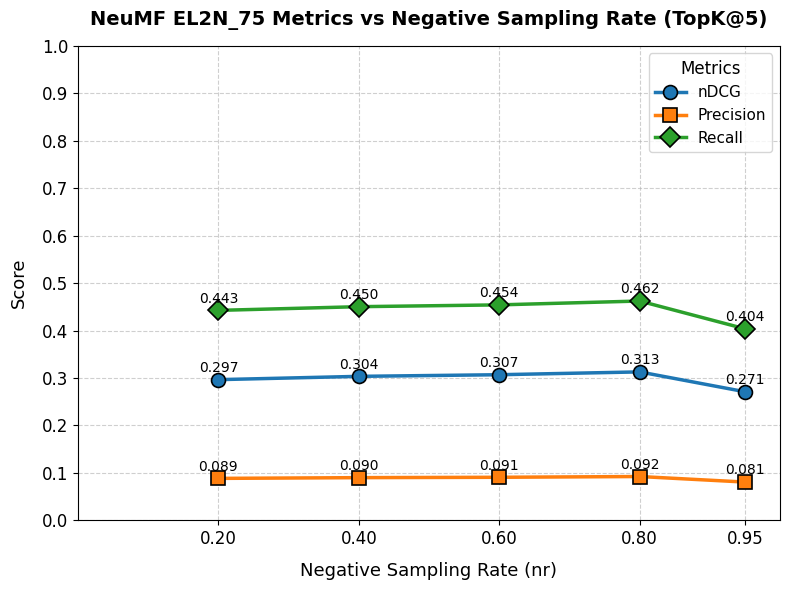

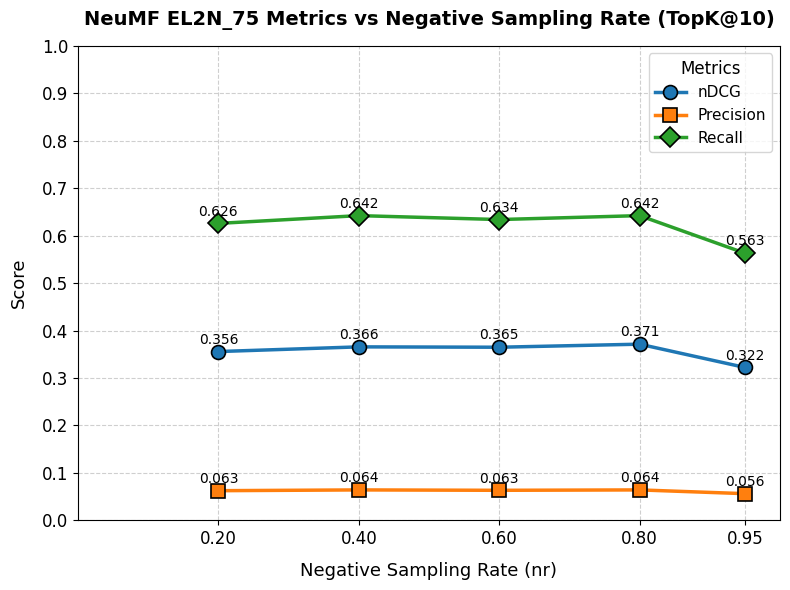

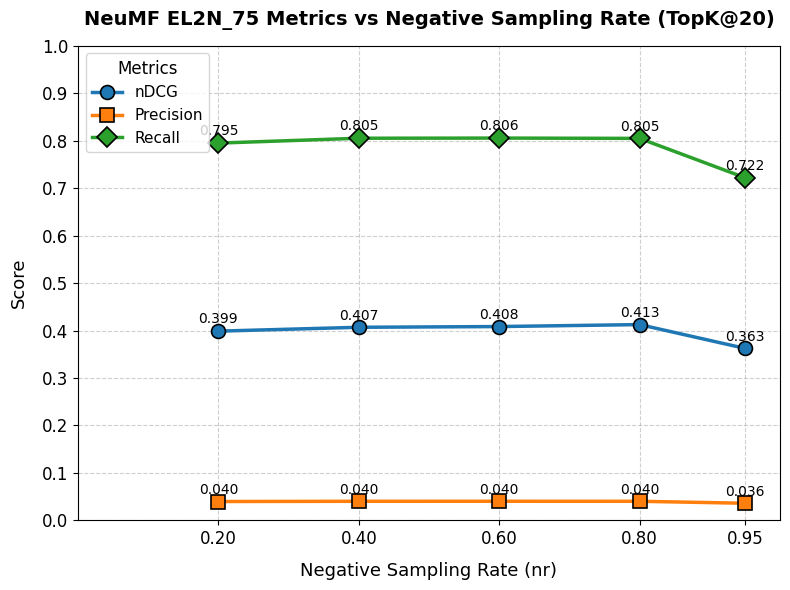

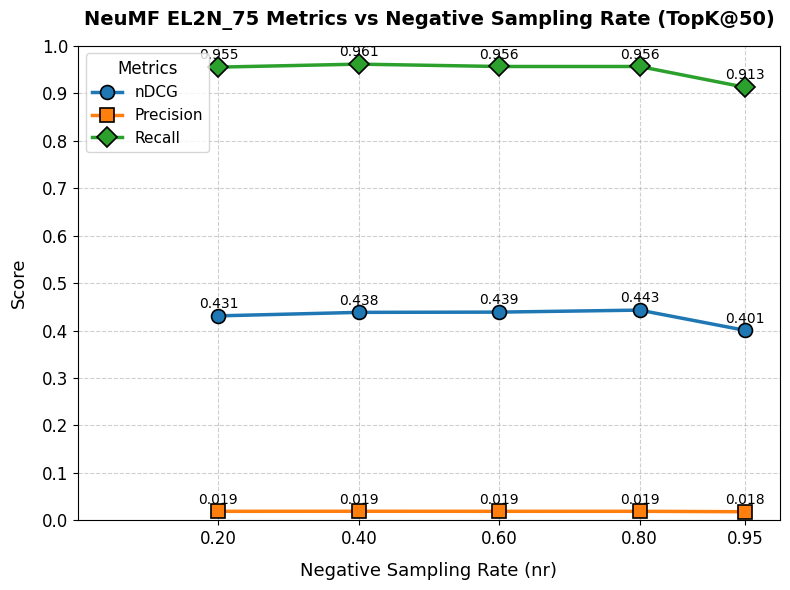

In [ ]:
markers = {
    "nDCG": "o",
    "Precision": "s",
    "Recall": "D"
}

# save_path_base = "/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/EL2N_75_results"

for topk, group in df.groupby("TopK"):
    plt.figure(figsize=(8, 6))
    
    for metric in ["nDCG", "Precision", "Recall"]:
        plt.plot(
            group["nr"],
            group[metric],
            marker=markers[metric],
            markersize=10,
            markeredgecolor="black",
            markeredgewidth=1.2,
            linewidth=2.5,
            label=metric
        )
        
        for x, y in zip(group["nr"], group[metric]):
            plt.text(
                x, y + 0.01,
                f"{y:.3f}",
                ha="center", va="bottom",
                fontsize=10,
                fontweight="medium",
                color="black"
            )

    plt.title(f"NeuMF EL2N_75 Metrics vs Negative Sampling Rate (TopK@{topk})",
              fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Negative Sampling Rate (nr)", fontsize=13, labelpad=10)
    plt.ylabel("Score", fontsize=13, labelpad=10)

    plt.xticks(group["nr"], fontsize=12, fontweight="medium")
    plt.yticks(np.arange(0, 1.05, 0.1), fontsize=12, fontweight="medium")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.legend(title="Metrics", fontsize=11, title_fontsize=12, loc="best")

    plt.tight_layout()
    # plt.savefig(f"{save_path_base}/NeuMF_TopK@{topk}_metrics_vs_nr.png", dpi=300)
    plt.show()


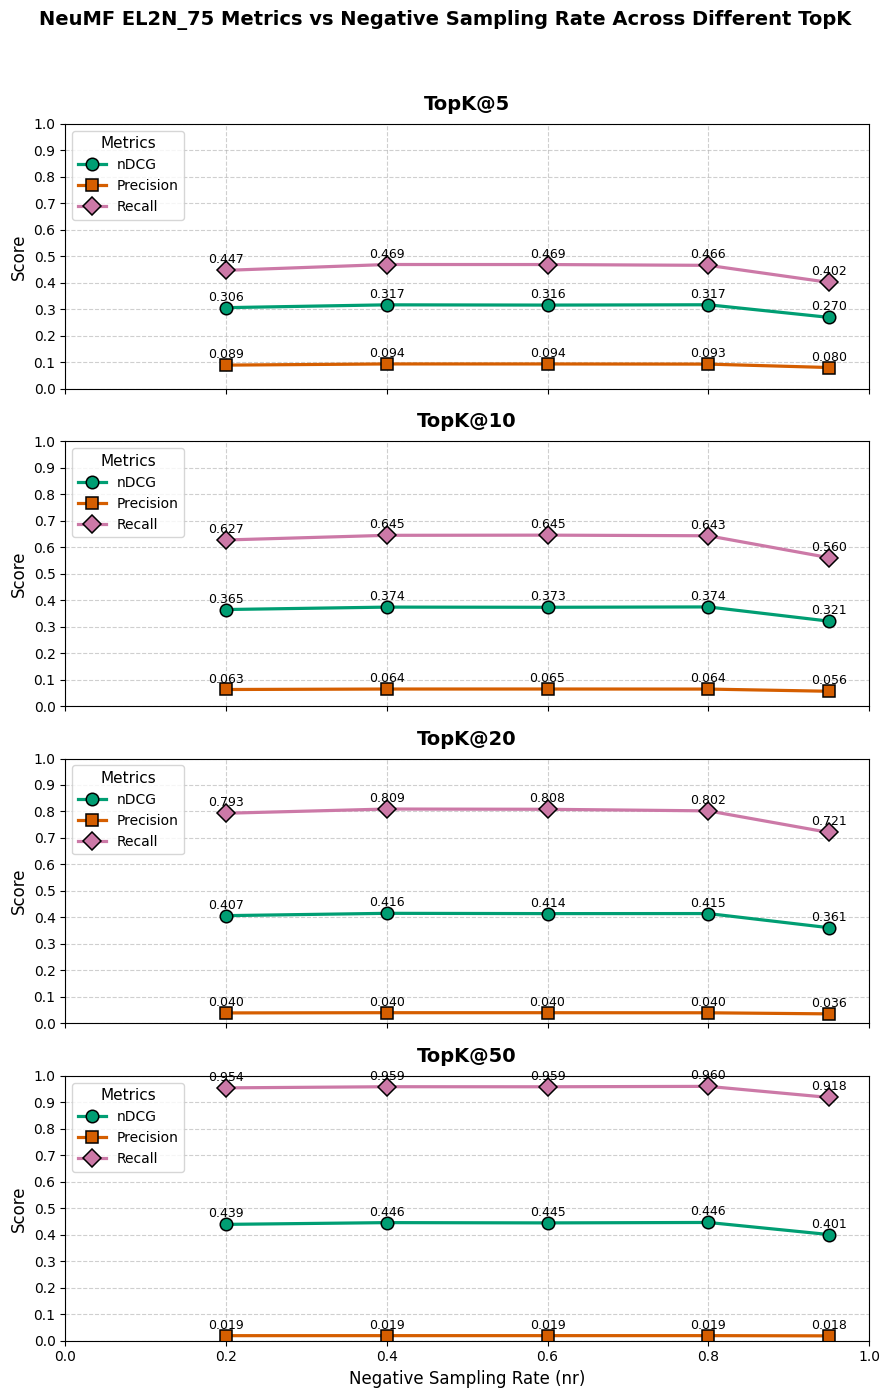

In [8]:
markers = {"nDCG": "o", "Precision": "s", "Recall": "D"}
colors = {"nDCG": "#009E73", "Precision": "#D55E00", "Recall": "#CC79A7"}
metrics = ["nDCG", "Precision", "Recall"]
topks = [5, 10, 20, 50]

fig, axes = plt.subplots(len(topks), 1, figsize=(9, 14), sharex=True)
fig.subplots_adjust(hspace=0.3)


for idx, topk in enumerate(topks):
    group = df[df["TopK"] == topk]
    ax = axes[idx]
    
    for metric in metrics:
        ax.plot(
            group["nr"],
            group[metric],
            marker=markers[metric],
            color=colors[metric],
            markersize=9,
            markeredgecolor="black",
            markeredgewidth=1.1,
            linewidth=2.3,
            label=metric
        )
        
        for x, y in zip(group["nr"], group[metric]):
            ax.text(x, y + 0.015, f"{y:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="medium")
    
    ax.set_title(f"TopK@{topk}", fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.05, 0.1))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Metrics", fontsize=10, title_fontsize=11, loc="upper left")

axes[-1].set_xlabel("Negative Sampling Rate (nr)", fontsize=12)
plt.suptitle("NeuMF EL2N_75 Metrics vs Negative Sampling Rate Across Different TopK", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig("/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/NeuMF_All_TopK_vs_NR.png", dpi=300)
plt.show()

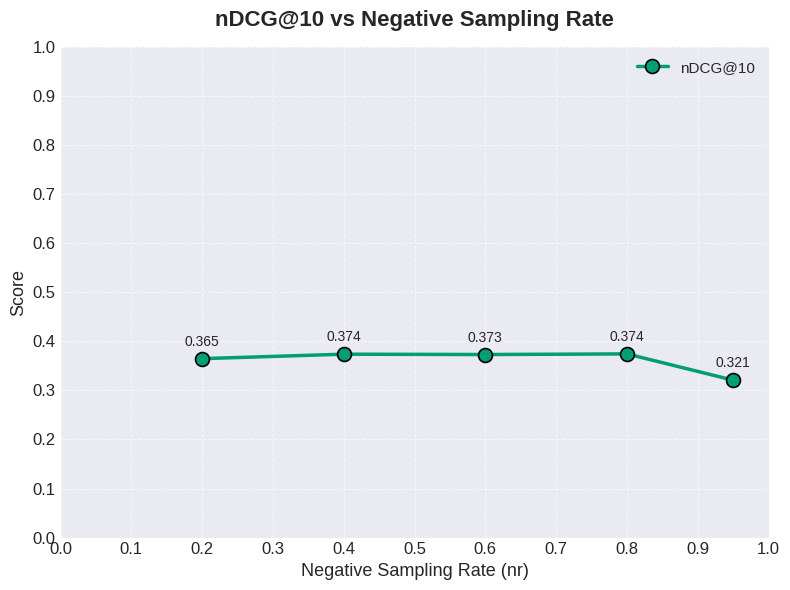

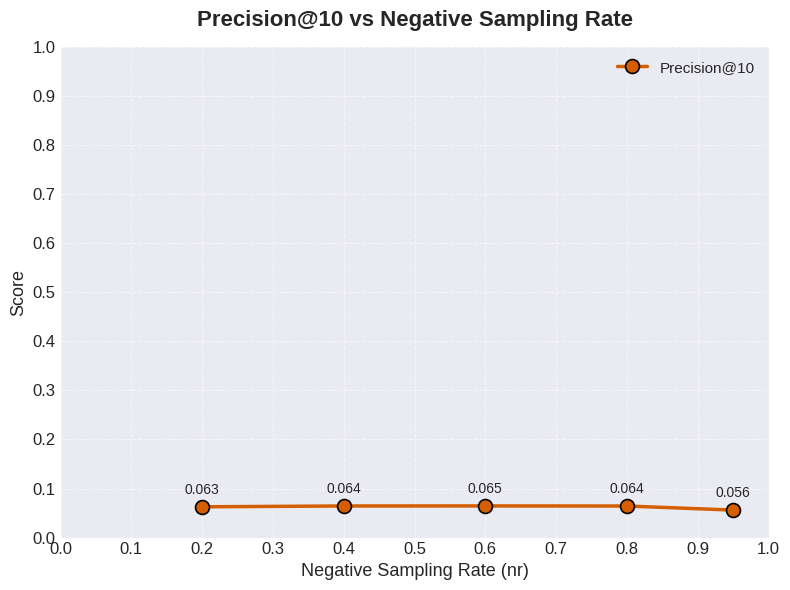

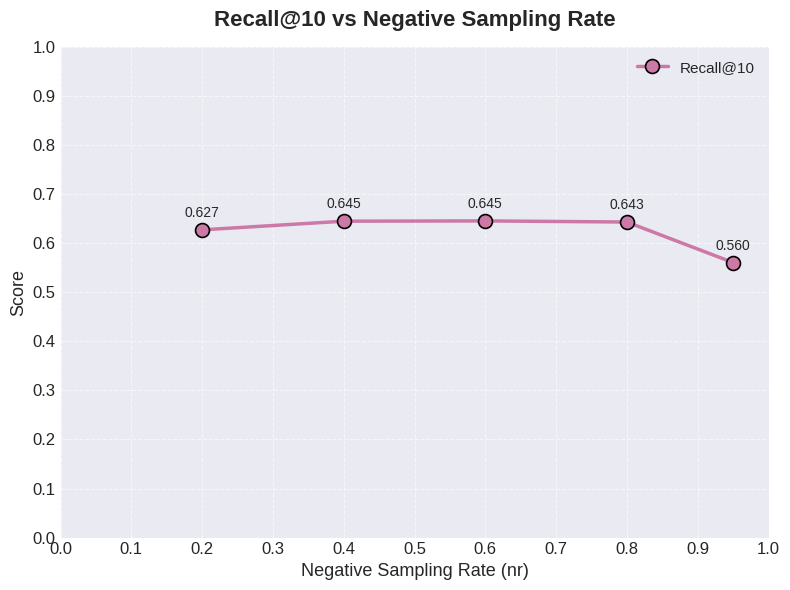

In [ ]:
metrics = ["nDCG", "Precision", "Recall"]
colors = {
    "nDCG": "#009E73",
    "Precision": "#D55E00",
    "Recall": "#CC79A7"
}

for metric in metrics:
    plt.figure(figsize=(8, 6))

    plt.plot(
        df["nr"],
        df[metric],
        marker='o',
        color=colors[metric],
        markersize=10,
        markeredgecolor='black',
        markeredgewidth=1.2,
        linewidth=2.5,
        label=f"{metric}@10"
    )

    for x, y in zip(df["nr"], df[metric]):
        plt.text(
            x, y + 0.02, f"{y:.3f}",
            ha='center', va='bottom',
            fontsize=10, fontweight='medium'
        )

    # Title and labels
    plt.title(f"{metric}@10 vs Negative Sampling Rate", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Negative Sampling Rate (nr)", fontsize=13)
    plt.ylabel("Score", fontsize=13)

    # Axis limits and ticks
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks([i/10 for i in range(0, 11)], fontsize=12, fontweight="medium")
    plt.yticks([i/10 for i in range(0, 11)], fontsize=12, fontweight="medium")

    # Grid and legend
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()

    # Save each plot separately
    # plt.savefig(f"plots/{metric.lower()}_vs_neg_samplerate.png", dpi=300)
    plt.show()
